# Exercise 2: Data preparation and exploration

# Part 1: Data structuring I <a id="structuring_1"></a>

We start with the `market_data_log.csv` dataset.

In [1]:
import pandas as pd
market_data_log_df = pd.read_csv("data/market_data_log.csv")
market_data_log_df.head()

<table class="dataframe caption-top table table-sm table-striped small" data-quarto-postprocess="true" data-border="1">

<thead>

<tr class="header">

<th data-quarto-table-cell-role="th">

</th>

<th data-quarto-table-cell-role="th">

timestamp

</th>

<th data-quarto-table-cell-role="th">

logger_sys

</th>

<th data-quarto-table-cell-role="th">

Record

</th>

</tr>

</thead>

<tbody>

<tr class="odd">

<td data-quarto-table-cell-role="th">

0

</td>

<td>

2024-10-16 00:00:00

</td>

<td>

FIN-PIPE-V1

</td>

<td>

SAP-DE-Tech-2023Q1-MarketCap-1154.9B

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

1

</td>

<td>

2023-04-25 00:00:00

</td>

<td>

FIN-PIPE-V1

</td>

<td>

SAP-DE-Tech-2023Q1-Revenue-475.6B

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

2

</td>

<td>

2023-01-26 00:00:00

</td>

<td>

FIN-PIPE-V1

</td>

<td>

SAP-DE-Tech-2023Q1-EBITDA-146.7B

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

3

</td>

<td>

2023-10-09 00:00:00

</td>

<td>

FIN-PIPE-V1

</td>

<td>

SAP-DE-Tech-2023Q2-MarketCap-1816.0B

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

4

</td>

<td>

2023-09-08 00:00:00

</td>

<td>

FIN-PIPE-V1

</td>

<td>

SAP-DE-Tech-2023Q2-Revenue-82.2B

</td>

</tr>

</tbody>

</table>

## Solution

### 1. Identify:

- **Values:** Examples: 2024-10-16 00:00:00, FIN-PIPE-V1, SAP, DE,
  2023Q1, 1154.9
- **Observations:** Individual logged measurements for a specific firm
  and period
- **Variables:** Timestamp, Logger system, Firm, Country, Sector,
  Period, MarketCap, Revenue, EBITDA
- **Units of observation:** One logged **firm–period** record
  (aggregating multiple metrics)

------------------------------------------------------------------------

### 2. Draft the **tidy structure** of the dataset (wide format):

| timestamp | logger_sys | Firm | Country | Sector | Period | MarketCap | Revenue | EBITDA |
|-----------------|-----------|-----|-------|------|------|---------|-------|------|
| 2024-10-16 00:00:00 | FIN-PIPE-V1 | SAP | DE | Tech | 2023Q1 | 1154.9B | 475.6B | 146.7B |
| 2023-10-09 00:00:00 | FIN-PIPE-V1 | SAP | DE | Tech | 2023Q2 | 1816.0B | 82.2B |  |
| … | … | … | … | … | … | … | … | … |

------------------------------------------------------------------------

### 3. Describe how the dataset should be transformed.

- **Parse encoded column:**

  - The `Record` column contains multiple variables concatenated with
    `-`
  - Split into: `Firm`, `Country`, `Sector`, `Period`, `Metric`, `Value`

- **Reshape (long → wide):**

  - Pivot the `Metric` column into separate columns (`MarketCap`,
    `Revenue`, `EBITDA`, …)
  - Use `Value` as cell entries

- **Optional refinement:**

  - Convert `Value` into numeric format (e.g., remove `B` and cast to
    float)
  - Keep or drop `timestamp` depending on whether it represents data
    collection or observation time

------------------------------------------------------------------------

### 4. (Optional challenge): Implement the transformation in Python (pandas)

In [3]:
import pandas as pd

# Load data
market_data_df = pd.read_csv("data/market_data_log.csv")

# Split encoded column
split_cols = market_data_df["Record"].str.split("-", expand=True)
split_cols.columns = ["Firm", "Country", "Sector", "Period", "Metric", "Value"]

# Combine with original dataframe
df = pd.concat([market_data_df, split_cols], axis=1)

# Pivot to wide format
df_wide = (
    df.pivot_table(
        index=["timestamp", "logger_sys", "Firm", "Country", "Sector", "Period"],
        columns="Metric",
        values="Value",
        aggfunc="first"
    )
    .reset_index()
)

df_wide.head()

------------------------------------------------------------------------



# Part 2: Data structuring II <a id="structuring_2"></a>

Dataset `sales_data_channels_full_year.csv`

In [4]:
import pandas as pd
sales_data_df = pd.read_csv("data/sales_data_channels_full_year.csv")
sales_data_df.head()

<table class="dataframe caption-top table table-sm table-striped small" data-quarto-postprocess="true" data-border="1">

<thead>

<tr class="header">

<th data-quarto-table-cell-role="th">

</th>

<th data-quarto-table-cell-role="th">

Customer_ID

</th>

<th data-quarto-table-cell-role="th">

Region

</th>

<th data-quarto-table-cell-role="th">

Jan_Online

</th>

<th data-quarto-table-cell-role="th">

Jan_Store

</th>

<th data-quarto-table-cell-role="th">

Feb_Online

</th>

<th data-quarto-table-cell-role="th">

Feb_Store

</th>

<th data-quarto-table-cell-role="th">

Mar_Online

</th>

<th data-quarto-table-cell-role="th">

Mar_Store

</th>

<th data-quarto-table-cell-role="th">

Apr_Online

</th>

<th data-quarto-table-cell-role="th">

Apr_Store

</th>

<th data-quarto-table-cell-role="th">

…

</th>

<th data-quarto-table-cell-role="th">

Aug_Online

</th>

<th data-quarto-table-cell-role="th">

Aug_Store

</th>

<th data-quarto-table-cell-role="th">

Sep_Online

</th>

<th data-quarto-table-cell-role="th">

Sep_Store

</th>

<th data-quarto-table-cell-role="th">

Oct_Online

</th>

<th data-quarto-table-cell-role="th">

Oct_Store

</th>

<th data-quarto-table-cell-role="th">

Nov_Online

</th>

<th data-quarto-table-cell-role="th">

Nov_Store

</th>

<th data-quarto-table-cell-role="th">

Dec_Online

</th>

<th data-quarto-table-cell-role="th">

Dec_Store

</th>

</tr>

</thead>

<tbody>

<tr class="odd">

<td data-quarto-table-cell-role="th">

0

</td>

<td>

ACC-E0IFD0

</td>

<td>

APAC

</td>

<td>

215

</td>

<td>

201

</td>

<td>

240

</td>

<td>

73

</td>

<td>

80

</td>

<td>

184

</td>

<td>

224

</td>

<td>

240

</td>

<td>

…

</td>

<td>

182

</td>

<td>

180

</td>

<td>

108

</td>

<td>

154

</td>

<td>

278

</td>

<td>

76

</td>

<td>

85

</td>

<td>

211

</td>

<td>

148

</td>

<td>

132

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

1

</td>

<td>

ACC-DPBHSA

</td>

<td>

EU

</td>

<td>

315

</td>

<td>

108

</td>

<td>

251

</td>

<td>

163

</td>

<td>

133

</td>

<td>

245

</td>

<td>

170

</td>

<td>

194

</td>

<td>

…

</td>

<td>

300

</td>

<td>

157

</td>

<td>

289

</td>

<td>

233

</td>

<td>

173

</td>

<td>

121

</td>

<td>

172

</td>

<td>

213

</td>

<td>

260

</td>

<td>

158

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

2

</td>

<td>

CUST-ZZPQK5

</td>

<td>

APAC

</td>

<td>

142

</td>

<td>

167

</td>

<td>

195

</td>

<td>

81

</td>

<td>

175

</td>

<td>

107

</td>

<td>

296

</td>

<td>

210

</td>

<td>

…

</td>

<td>

101

</td>

<td>

221

</td>

<td>

141

</td>

<td>

116

</td>

<td>

142

</td>

<td>

109

</td>

<td>

182

</td>

<td>

55

</td>

<td>

258

</td>

<td>

124

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

3

</td>

<td>

CUST-ZMF8MD

</td>

<td>

APAC

</td>

<td>

218

</td>

<td>

209

</td>

<td>

154

</td>

<td>

224

</td>

<td>

205

</td>

<td>

163

</td>

<td>

124

</td>

<td>

206

</td>

<td>

…

</td>

<td>

83

</td>

<td>

228

</td>

<td>

264

</td>

<td>

172

</td>

<td>

235

</td>

<td>

223

</td>

<td>

239

</td>

<td>

88

</td>

<td>

285

</td>

<td>

178

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

4

</td>

<td>

CUST-MMJBQE

</td>

<td>

EU

</td>

<td>

180

</td>

<td>

145

</td>

<td>

212

</td>

<td>

135

</td>

<td>

217

</td>

<td>

124

</td>

<td>

231

</td>

<td>

190

</td>

<td>

…

</td>

<td>

253

</td>

<td>

151

</td>

<td>

115

</td>

<td>

78

</td>

<td>

159

</td>

<td>

194

</td>

<td>

140

</td>

<td>

219

</td>

<td>

111

</td>

<td>

137

</td>

</tr>

</tbody>

</table>

<p>

5 rows × 26 columns

</p>

## Solution

### 1. Identify:

- Values: Numerical sales values (215, 201, 240, …)
- Observations: Individual sales measurements for a specific customer,
  month, and channel
- Variables: CustomerID, Region, Month, Channel, Sales
- Units of observation: A customer–month–channel combination

### 2. Draft the **tidy structure** of the dataset:

| Customer_ID | Region | Month | Channel | Sales |
|-------------|--------|-------|---------|-------|
| CUST-AB12CD | EU     | Jan   | Online  | 120   |
| CUST-AB12CD | EU     | Jan   | Store   | 95    |
| CUST-AB12CD | EU     | Feb   | Online  | 135   |



### 3. Describe how the dataset should be transformed.

- Reshape (wide → long): Convert all monthly/channel columns into two
  columns
- Split the combined column (Month, Channel)

### 4. (Optional challenge): Implement the transformation in Python (pandas)

In [6]:
import pandas as pd

# Load data
sales_data_df = pd.read_csv("data/sales_data_channels_full_year.csv")

# Step 1: reshape to long format
tidy_df = sales_data_df.melt(
    id_vars=["Customer_ID", "Region"],
    var_name="Month_Channel",
    value_name="Sales"
)

# Step 2: split Month and Channel
tidy_df[["Month", "Channel"]] = tidy_df["Month_Channel"].str.split("_", expand=True)

# Step 3: drop Month_Channel
tidy_df.drop(columns=["Month_Channel"], inplace=True)

tidy_df.head()

------------------------------------------------------------------------



# Part 3: Data cleansing <a id="cleansing"></a>

Dataset `messy_customer_data.csv`

In [7]:
import pandas as pd
customers_df = pd.read_csv("data/messy_customer_data.csv")
customers_df.head()

<table class="dataframe caption-top table table-sm table-striped small" data-quarto-postprocess="true" data-border="1">

<thead>

<tr class="header">

<th data-quarto-table-cell-role="th">

</th>

<th data-quarto-table-cell-role="th">

customer_id

</th>

<th data-quarto-table-cell-role="th">

date_of_birth

</th>

<th data-quarto-table-cell-role="th">

income

</th>

<th data-quarto-table-cell-role="th">

gender

</th>

<th data-quarto-table-cell-role="th">

signup_date

</th>

<th data-quarto-table-cell-role="th">

country

</th>

</tr>

</thead>

<tbody>

<tr class="odd">

<td data-quarto-table-cell-role="th">

0

</td>

<td>

CUST_00000001809

</td>

<td>

1980-04-09

</td>

<td>

4896 USD

</td>

<td>

M

</td>

<td>

2026-12-14

</td>

<td>

USA

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

1

</td>

<td>

CUST_00000000695

</td>

<td>

1945-08-02

</td>

<td>

7029

</td>

<td>

F

</td>

<td>

2023-11-26

</td>

<td>

BR

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

2

</td>

<td>

CUST_00000000907

</td>

<td>

1971-07-25

</td>

<td>

6432

</td>

<td>

F

</td>

<td>

2024-06-25

</td>

<td>

Austria

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

3

</td>

<td>

CUST_00000000545

</td>

<td>

2000-03-01

</td>

<td>

6107

</td>

<td>

M

</td>

<td>

2023-06-29

</td>

<td>

JP

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

4

</td>

<td>

CUST_00000001848

</td>

<td>

1943-09-06

</td>

<td>

7655

</td>

<td>

F

</td>

<td>

2027-01-22

</td>

<td>

Italy

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

5

</td>

<td>

CUST_00000001567

</td>

<td>

1980-09-14

</td>

<td>

2244

</td>

<td>

F

</td>

<td>

2026-04-16

</td>

<td>

CH

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

6

</td>

<td>

CUST_00000001573

</td>

<td>

1950-04-07

</td>

<td>

3262

</td>

<td>

F

</td>

<td>

2026-04-22

</td>

<td>

India

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

7

</td>

<td>

CUST_00000000945

</td>

<td>

1989-08-23

</td>

<td>

3976

</td>

<td>

M

</td>

<td>

2024-08-02

</td>

<td>

BR

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

8

</td>

<td>

CUST_00000000819

</td>

<td>

1946-03-09

</td>

<td>

3077 USD

</td>

<td>

F

</td>

<td>

2024-03-29

</td>

<td>

NL

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

9

</td>

<td>

CUST_00000000830

</td>

<td>

1981-03-30

</td>

<td>

NaN

</td>

<td>

M

</td>

<td>

2024-04-09

</td>

<td>

BR

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

10

</td>

<td>

CUST_00000001531

</td>

<td>

1995-03-08

</td>

<td>

4667

</td>

<td>

F

</td>

<td>

2026-03-11

</td>

<td>

DE

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

11

</td>

<td>

CUST_00000000979

</td>

<td>

1990-01-24

</td>

<td>

NaN

</td>

<td>

F

</td>

<td>

2024-09-05

</td>

<td>

Switzerland

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

12

</td>

<td>

CUST_00000001576

</td>

<td>

1989-06-18

</td>

<td>

2920

</td>

<td>

F

</td>

<td>

2026-04-25

</td>

<td>

Brazil

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

13

</td>

<td>

CUST_00000000786

</td>

<td>

1994-06-24

</td>

<td>

6613

</td>

<td>

F

</td>

<td>

2024-02-25

</td>

<td>

IT

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

14

</td>

<td>

CUST_00000000071

</td>

<td>

1960-11-19

</td>

<td>

4613

</td>

<td>

F

</td>

<td>

2022-03-12

</td>

<td>

FR

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

15

</td>

<td>

CUST_00000001007

</td>

<td>

1989-07-09

</td>

<td>

4551

</td>

<td>

F

</td>

<td>

2024-10-03

</td>

<td>

BR

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

16

</td>

<td>

CUST_00000000189

</td>

<td>

1969-01-29

</td>

<td>

6779

</td>

<td>

M

</td>

<td>

2022-07-08

</td>

<td>

China

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

17

</td>

<td>

CUST_00000001670

</td>

<td>

1987-08-04

</td>

<td>

7295

</td>

<td>

M

</td>

<td>

2026-07-28

</td>

<td>

Munch

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

18

</td>

<td>

CUST_00000001270

</td>

<td>

1969-02-06

</td>

<td>

4717

</td>

<td>

F

</td>

<td>

2025-06-23

</td>

<td>

USA

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

19

</td>

<td>

CUST_00000001305

</td>

<td>

1989-01-13

</td>

<td>

7954

</td>

<td>

F

</td>

<td>

2025-07-28

</td>

<td>

ES

</td>

</tr>

</tbody>

</table>



## Solution

### 1. Identify scales of variables

- What type of scale is each variable?

  All are `nominal` (strings).

- What type of scale should each variable be? Assign `nominal`,
  `ordinal`, `interval`, or `ratio`.

  - customer_id: **nominal**
  - date_of_birth: **interval**
  - income: **ratio**
  - gender: **nominal**
  - signup_date: **interval**
  - country: **nominal**

### 2. Analyze data quality

Examine the dataset `data/messy_customer_data.csv` and run the
following:

In [11]:
customer_df.describe()

- Summarize all data quality issues you observe.

- **Missing values**

  - `date_of_birth`
  - `income`
  - `signup_date`

- **Implausible / invalid values**

  - `date_of_birth` (e.g., 1890, future dates like 2030)
  - `signup_date` (e.g., invalid dates like 2023-13-01)
  - `income` (e.g., negative values)



- **Inconsistent formats**
  - `income` (e.g., “5000”, “5000 EUR”, “5000 USD”)
  - `signup_date` (multiple date formats)
- **Outliers**
  - `income` (e.g., very high values like 200000)
- **Inconsistent categorical values**
  - `gender` (M, F, Male, Female, m, f)
  - `country` (codes, names, typos: DE, Germany, Ger, U.S., Brasil,
    etc.)
- **Duplicates**
  - Duplicate records identifiable via repeated `customer_id` (high
    frequency)

------------------------------------------------------------------------

### 3. Propose data preparation steps

- For each data quality issue, suggest how you would address it.

- **Missing values:** impute (e.g., median for income) or remove rows

- **Implausible / invalid values:** filter out or correct (e.g.,
  negative income, invalid dates)

- **Inconsistent formats:** standardize (convert income to numeric,
  parse dates to datetime)

- **Outliers:** inspect and cap or remove extreme values

- **Inconsistent categorical values:** unify categories (e.g., gender
  labels, country formats)

- **Duplicates:** remove duplicates based on `customer_id`

------------------------------------------------------------------------

### 4. *(Optional challenge)* Implement in Python (pandas)

In [12]:
import pandas as pd

customer_df = pd.read_csv("data/messy_customer_data.csv")

# --- Income: clean + numeric ---
customer_df["income"] = (
    customer_df["income"]
    .astype(str)
    .str.replace(r"\s*(USD|EUR)", "", regex=True)
)
customer_df["income"] = pd.to_numeric(customer_df["income"], errors="coerce")

# --- Missing values (income) ---
customer_df["income"] = customer_df["income"].fillna(customer_df["income"].median())

# --- Dates: parse ---
customer_df["date_of_birth"] = pd.to_datetime(customer_df["date_of_birth"], errors="coerce")
customer_df["signup_date"] = pd.to_datetime(customer_df["signup_date"], errors="coerce")

# --- Invalid / implausible values ---
today = pd.Timestamp.today()

# remove future DOB and very old values
customer_df = customer_df[
    (customer_df["date_of_birth"] < today) &
    (customer_df["date_of_birth"] > pd.Timestamp("1900-01-01"))
]

# remove invalid signup dates (future or NaT)
customer_df = customer_df[
    (customer_df["signup_date"] <= today)
]

# remove negative income
customer_df = customer_df[customer_df["income"] >= 0]

# --- Outliers (simple cap) ---
upper_cap = customer_df["income"].quantile(0.99)
customer_df["income"] = customer_df["income"].clip(upper=upper_cap)

# --- Gender standardization ---
customer_df["gender"] = customer_df["gender"].replace({
    "M": "Male", "m": "Male",
    "F": "Female", "f": "Female"
})

# --- Country standardization ---
country_map = {
    "Germany": "DE", "Ger": "DE", "DEU": "DE",
    "USA": "US", "U.S.": "US",
    "UK ": "UK",
    "France": "FR",
    "Spain": "ES",
    "Italy": "IT",
    "Netherlands": "NL",
    "Switzerland": "CH",
    "Austria": "AT",
    "China": "CN",
    "Japan": "JP",
    "India": "IN",
    "Brazil": "BR", "Brasil": "BR",
    "Canada": "CA",
    "Munch": "DE"
}
customer_df["country"] = customer_df["country"].replace(country_map)

# --- Remove duplicates ---
customer_df = customer_df.drop_duplicates(subset=["customer_id"])

customer_df.head()

------------------------------------------------------------------------



# Part 4: EDA: Clustering <a id="clustering"></a>

Now that the data is structured and cleaned, we explore whether
companies group into similar patterns. Clustering helps us move from
preparation to insight generation: instead of looking at firms one by
one, we ask whether there are recurring profiles in the data.

Dataset: `firm_data.csv`

In [13]:
import pandas as pd
firm_data_df = pd.read_csv("data/firm_data.csv")
firm_data_df.head()

<table class="dataframe caption-top table table-sm table-striped small" data-quarto-postprocess="true" data-border="1">

<thead>

<tr class="header">

<th data-quarto-table-cell-role="th">

</th>

<th data-quarto-table-cell-role="th">

company_id

</th>

<th data-quarto-table-cell-role="th">

sector

</th>

<th data-quarto-table-cell-role="th">

revenue

</th>

<th data-quarto-table-cell-role="th">

profit_margin

</th>

<th data-quarto-table-cell-role="th">

growth_rate

</th>

<th data-quarto-table-cell-role="th">

debt_ratio

</th>

<th data-quarto-table-cell-role="th">

market_cap

</th>

<th data-quarto-table-cell-role="th">

rd_intensity

</th>

</tr>

</thead>

<tbody>

<tr class="odd">

<td data-quarto-table-cell-role="th">

0

</td>

<td>

FIRM-0095

</td>

<td>

Healthcare

</td>

<td>

2117.569743

</td>

<td>

13.382162

</td>

<td>

6.053507

</td>

<td>

0.555974

</td>

<td>

12426.889897

</td>

<td>

3.308879

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

1

</td>

<td>

FIRM-0015

</td>

<td>

Healthcare

</td>

<td>

457.538045

</td>

<td>

10.139487

</td>

<td>

21.504950

</td>

<td>

0.350252

</td>

<td>

5779.074618

</td>

<td>

8.710809

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

2

</td>

<td>

FIRM-0030

</td>

<td>

Industry

</td>

<td>

463.847307

</td>

<td>

4.131422

</td>

<td>

13.237034

</td>

<td>

0.356084

</td>

<td>

4451.965515

</td>

<td>

15.719744

</td>

</tr>

<tr class="even">

<td data-quarto-table-cell-role="th">

3

</td>

<td>

FIRM-0158

</td>

<td>

Finance

</td>

<td>

347.980562

</td>

<td>

9.573304

</td>

<td>

16.117482

</td>

<td>

0.472141

</td>

<td>

3256.609038

</td>

<td>

31.989645

</td>

</tr>

<tr class="odd">

<td data-quarto-table-cell-role="th">

4

</td>

<td>

FIRM-0128

</td>

<td>

Tech

</td>

<td>

804.239654

</td>

<td>

0.165357

</td>

<td>

-3.346796

</td>

<td>

0.761088

</td>

<td>

1825.004761

</td>

<td>

2.082579

</td>

</tr>

</tbody>

</table>

## Solution

### 1. Prepare the data for clustering

We use only `profit_margin` and `rd_intensity` for clustering:

In [22]:
import pandas as pd

df_firm_data = pd.read_csv("data/firm_data.csv")

X = df_firm_data[["profit_margin", "rd_intensity"]]

X.head()

#### Exploratory check

In [23]:
X.describe()

array([[<Axes: title={'center': 'profit_margin'}>,
        <Axes: title={'center': 'rd_intensity'}>]], dtype=object)

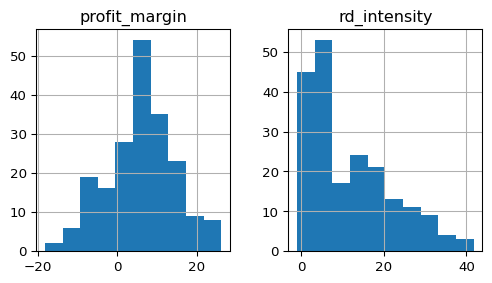

In [24]:
df_firm_data[["profit_margin", "rd_intensity"]].hist(figsize=(6, 3))

These summaries and histograms help us understand the distribution and
scale of the variables.



#### Standardization

Since k-means is sensitive to scale differences, we standardize the
variables:

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:3]

array([[ 0.85543951, -0.83428853],
       [ 0.47771828, -0.30244699],
       [-0.22212786,  0.38761056]])

#### Scatterplot (before clustering)

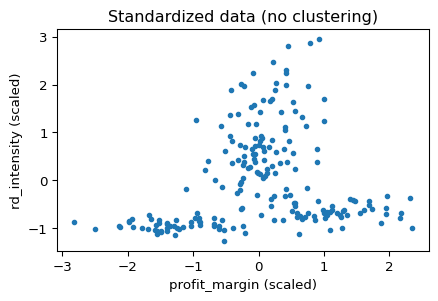

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 3))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], s=10)
plt.title("Standardized data (no clustering)")
plt.xlabel("profit_margin (scaled)")
plt.ylabel("rd_intensity (scaled)")
plt.show()

**Interpretation:** From the scatterplot, we might expect a small number
of clusters (e.g., 3–5), depending on visible groupings.



### 2. Apply K-Means clustering

We try different values of `k` and visually inspect the cluster
structure:

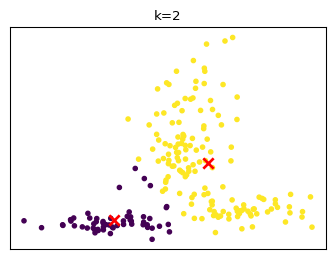

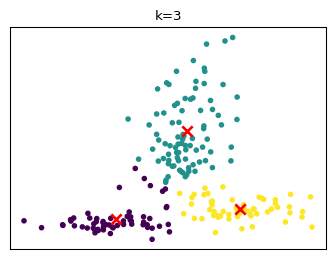

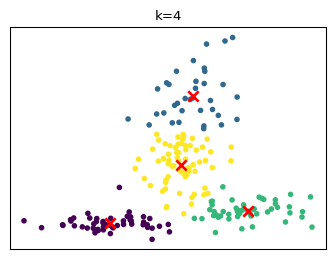

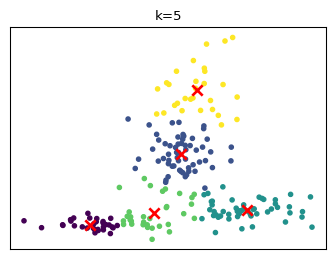

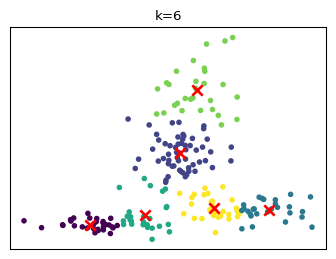

In [27]:
from sklearn.cluster import KMeans

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    plt.figure(figsize=(3.6, 2.8))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=10)
    plt.scatter(
        kmeans.cluster_centers_[:, 0],
        kmeans.cluster_centers_[:, 1],
        c="red", marker="x", s=60, linewidth=2
    )
    plt.title(f"k={k}", fontsize=10)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()

**Conclusion:** A value around **k = 4** appears to provide a reasonable
balance between simplicity and structure.



### 3. Add cluster labels to the dataset

We now fit the final model and store the cluster labels:

In [28]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_scaled)

df_firm_data["cluster"] = labels

df_firm_data.head()



### 4. Create grouped boxplots

We compare `revenue` across clusters:

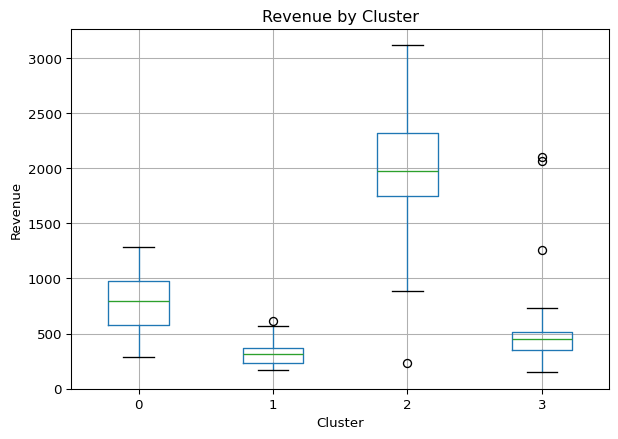

In [29]:
import matplotlib.pyplot as plt

df_firm_data.boxplot(column="revenue", by="cluster")
plt.title("Revenue by Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Revenue")
plt.show()

**Interpretation:** The boxplots reveal how revenue differs across
clusters, helping to characterize the identified firm profiles.